# Telecom Customer Churn Prediction

This project combines **Exploratory Data Analysis, SQL business analysis and Machine Learning** to understand why telecom customers leave and to predict churn.

The workflow is intentionally practical: clean the data, investigate important customer segments, answer business questions with SQL, compare several classification algorithms, and select a useful final model.

## 1. Importing Libraries and Loading Data

In [2]:
from pathlib import Path
import sqlite3
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.base import clone

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "telco_customer_churn.csv"
OUTPUT_PATH = ROOT / "output"
OUTPUT_PATH.mkdir(exist_ok=True)

data = pd.read_csv(DATA_PATH)
data.head()
# Plotting setup for consistent rendering across notebook environments
sns.set_theme(style="whitegrid")
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#B279A2"])


## 2. Understanding the Dataset

In [3]:
print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())
print("\nData types:")
display(data.dtypes.to_frame("dtype"))
print("\nBasic statistics:")
display(data.describe(include="all").T)

Dataset shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Checking Missing Values

In [4]:
missing = data.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_values"))

print("Blank TotalCharges values:", (data["TotalCharges"].astype(str).str.strip() == "").sum())

,missing_values


Blank TotalCharges values: 11


### Data Cleaning

`TotalCharges` contains blank values for customers with zero tenure. These values are converted to numeric and treated as `0`, which is consistent with a customer who has not accumulated charges yet.

The customer ID is retained in the raw data but removed before modelling because it is an identifier, not a predictive feature.

In [5]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["TotalCharges"] = data["TotalCharges"].fillna(0)

print("Missing TotalCharges after cleaning:", data["TotalCharges"].isna().sum())
print("Zero-tenure customers:", (data["tenure"] == 0).sum())

data["ChurnFlag"] = data["Churn"].map({"No": 0, "Yes": 1})
data.head()

Missing TotalCharges after cleaning: 0
Zero-tenure customers: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## 4. Exploratory Data Analysis

### 1. Churn Distribution

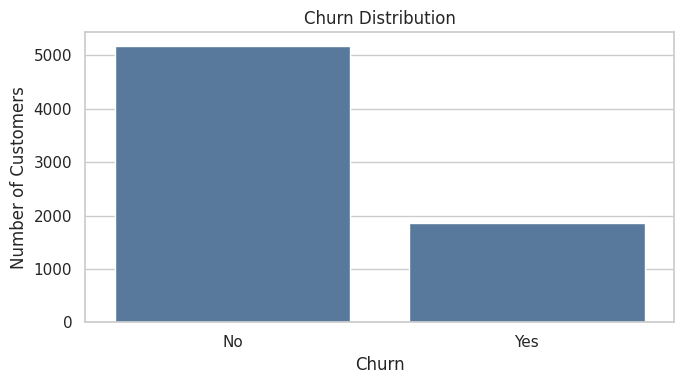

Overall churn rate: 26.54%


In [5]:
churn_counts = data["Churn"].value_counts().reindex(["No", "Yes"])
plt.figure(figsize=(7, 4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, color=sns.color_palette()[0])
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "Churn Distribution.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"Overall churn rate: {data['ChurnFlag'].mean()*100:.2f}%")

### 2. Churn Distribution with Respect to Gender

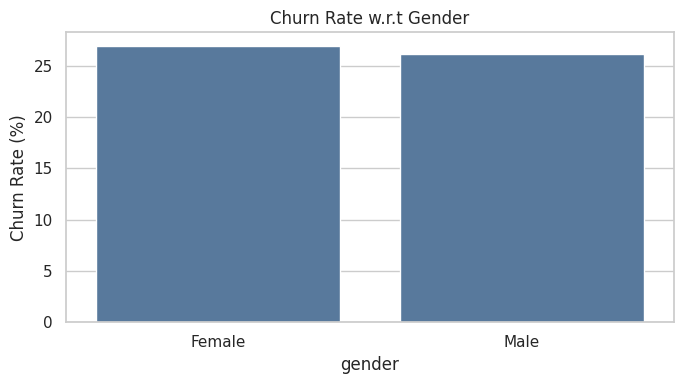

,gender,Churn Rate
0,Female,26.92
1,Male,26.16


In [6]:
gender_rate = data.groupby("gender")["ChurnFlag"].mean().mul(100).reset_index(name="Churn Rate")
plt.figure(figsize=(7, 4))
sns.barplot(data=gender_rate, x="gender", y="Churn Rate", color=sns.color_palette()[0])
plt.title("Churn Rate w.r.t Gender")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "distributionWRTGender.PNG", dpi=160, bbox_inches="tight")
plt.show()

display(gender_rate.round(2))

### 3. Customer Contract Distribution

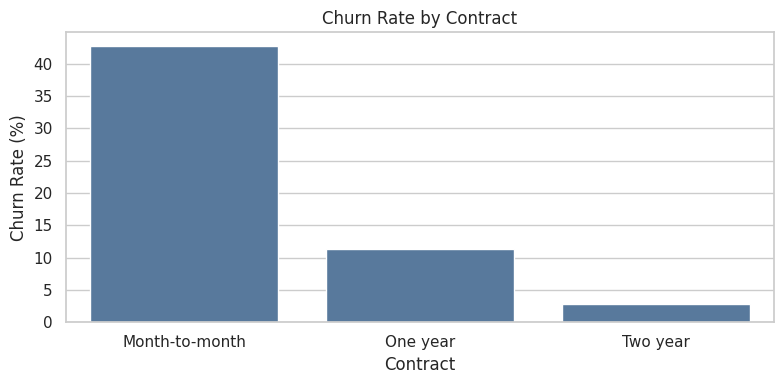

,Contract,Churn Rate
0,Month-to-month,42.71
1,One year,11.27
2,Two year,2.83


In [7]:
contract_rate = data.groupby("Contract")["ChurnFlag"].mean().mul(100).reset_index(name="Churn Rate")
plt.figure(figsize=(8, 4))
sns.barplot(data=contract_rate, x="Contract", y="Churn Rate", color=sns.color_palette()[0])
plt.title("Churn Rate by Contract")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "Contract distribution.png", dpi=160, bbox_inches="tight")
plt.show()

display(contract_rate.round(2))

### 4. Payment Methods

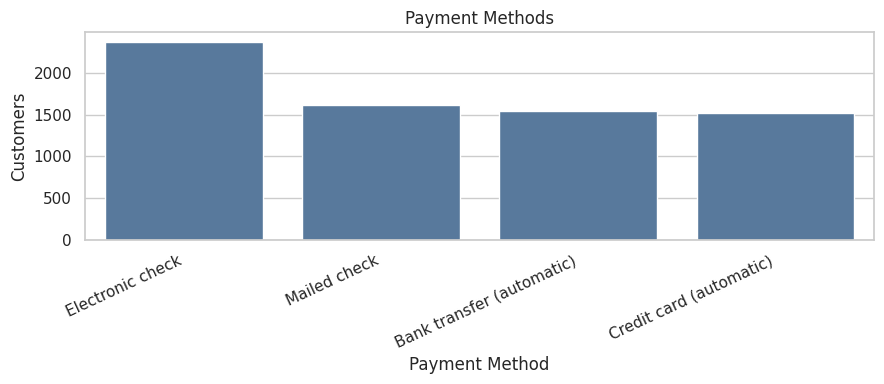

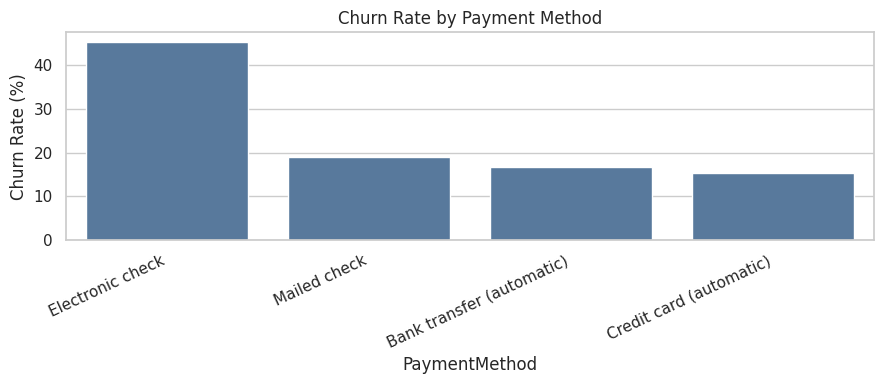

,churn_rate_pct
PaymentMethod,
Electronic check,45.29
Mailed check,19.11
Bank transfer (automatic),16.71
Credit card (automatic),15.24


In [8]:
payment_counts = data["PaymentMethod"].value_counts()
plt.figure(figsize=(9, 4))
sns.barplot(x=payment_counts.index, y=payment_counts.values, color=sns.color_palette()[0])
plt.title("Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Customers")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "payment methods.png", dpi=160, bbox_inches="tight")
plt.show()

payment_rate = data.groupby("PaymentMethod")["ChurnFlag"].mean().mul(100).sort_values(ascending=False)
plt.figure(figsize=(9, 4))
sns.barplot(x=payment_rate.index, y=payment_rate.values, color=sns.color_palette()[0])
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "payment ethods with respectto churn.PNG", dpi=160, bbox_inches="tight")
plt.show()

display(payment_rate.round(2).to_frame("churn_rate_pct"))

### 5. Internet Services

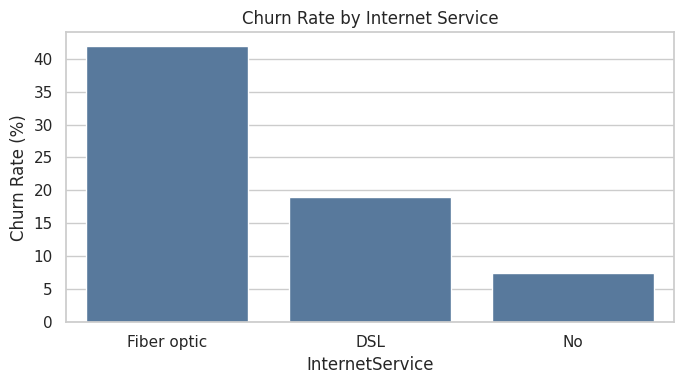

,churn_rate_pct
InternetService,
Fiber optic,41.89
DSL,18.96
No,7.40


In [9]:
internet_rate = data.groupby("InternetService")["ChurnFlag"].mean().mul(100).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=internet_rate.index, y=internet_rate.values, color=sns.color_palette()[0])
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "internet services.PNG", dpi=160, bbox_inches="tight")
plt.show()

display(internet_rate.round(2).to_frame("churn_rate_pct"))

### 6. Dependents

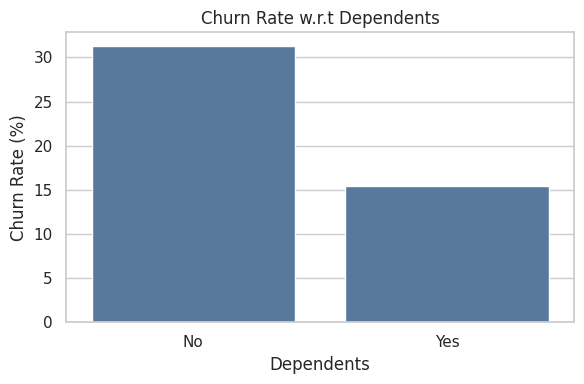

In [10]:
dependent_rate = data.groupby("Dependents")["ChurnFlag"].mean().mul(100)
plt.figure(figsize=(6, 4))
sns.barplot(x=dependent_rate.index, y=dependent_rate.values, color=sns.color_palette()[0])
plt.title("Churn Rate w.r.t Dependents")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "dependents.PNG", dpi=160, bbox_inches="tight")
plt.show()

### 7. Online Security

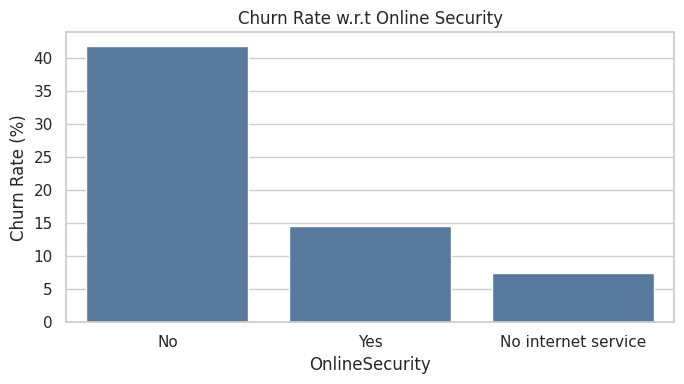

In [11]:
security_rate = data.groupby("OnlineSecurity")["ChurnFlag"].mean().mul(100).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=security_rate.index, y=security_rate.values, color=sns.color_palette()[0])
plt.title("Churn Rate w.r.t Online Security")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "onlineSecurity.PNG", dpi=160, bbox_inches="tight")
plt.show()

### 8. Senior Citizen

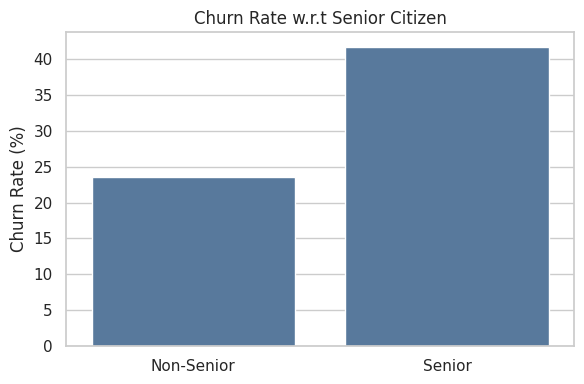

In [12]:
senior_rate = data.groupby("SeniorCitizen")["ChurnFlag"].mean().mul(100)
labels = ["Non-Senior", "Senior"]
values = [senior_rate.get(0, 0), senior_rate.get(1, 0)]
plt.figure(figsize=(6, 4))
sns.barplot(x=labels, y=values, color=sns.color_palette()[0])
plt.title("Churn Rate w.r.t Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "seniorCitzen.PNG", dpi=160, bbox_inches="tight")
plt.show()

### 9. Paperless Billing

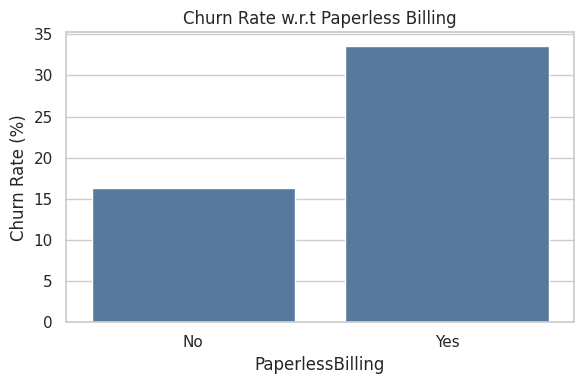

In [13]:
billing_rate = data.groupby("PaperlessBilling")["ChurnFlag"].mean().mul(100)
plt.figure(figsize=(6, 4))
sns.barplot(x=billing_rate.index, y=billing_rate.values, color=sns.color_palette()[0])
plt.title("Churn Rate w.r.t Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "billing.PNG", dpi=160, bbox_inches="tight")
plt.show()

### 10. Tech Support

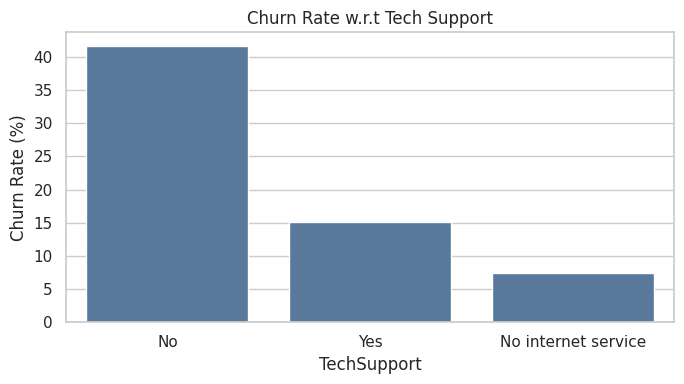

In [14]:
tech_rate = data.groupby("TechSupport")["ChurnFlag"].mean().mul(100).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=tech_rate.index, y=tech_rate.values, color=sns.color_palette()[0])
plt.title("Churn Rate w.r.t Tech Support")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "techSupport.PNG", dpi=160, bbox_inches="tight")
plt.show()

### 11. Distribution w.r.t Charges and Tenure

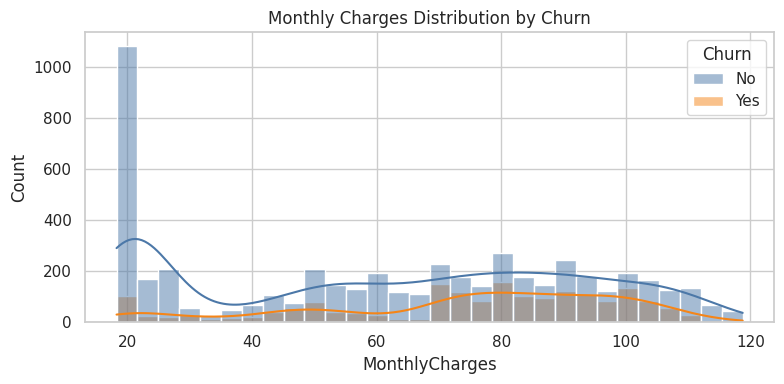

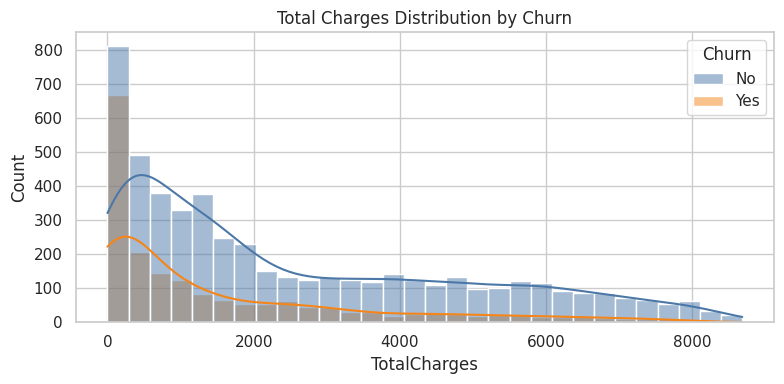

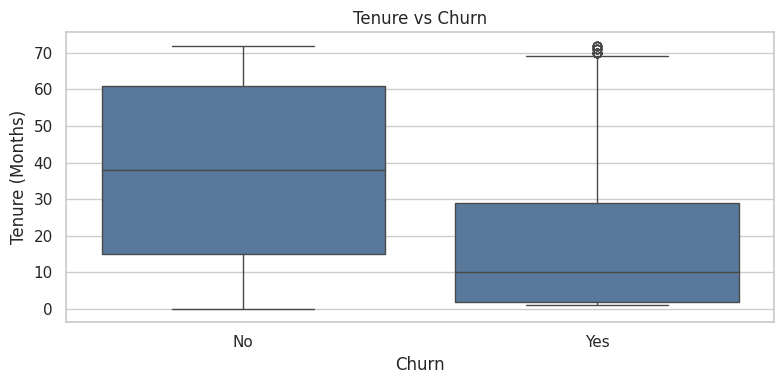

,MonthlyCharges,TotalCharges,tenure
Churn,,,
No,61.27,2549.91,37.57
Yes,74.44,1531.80,17.98


In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=data, x="MonthlyCharges", hue="Churn", bins=30, kde=True, ax=ax)
ax.set_title("Monthly Charges Distribution by Churn")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "carges distribution.PNG", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=data, x="TotalCharges", hue="Churn", bins=30, kde=True, ax=ax)
ax.set_title("Total Charges Distribution by Churn")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "total charges.PNG", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=data, x="Churn", y="tenure")
ax.set_title("Tenure vs Churn")
ax.set_ylabel("Tenure (Months)")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "tenure and churn.PNG", dpi=160, bbox_inches="tight")
plt.show()

display(data.groupby("Churn")[["MonthlyCharges", "TotalCharges", "tenure"]].mean().round(2))

### 12. Correlation Overview

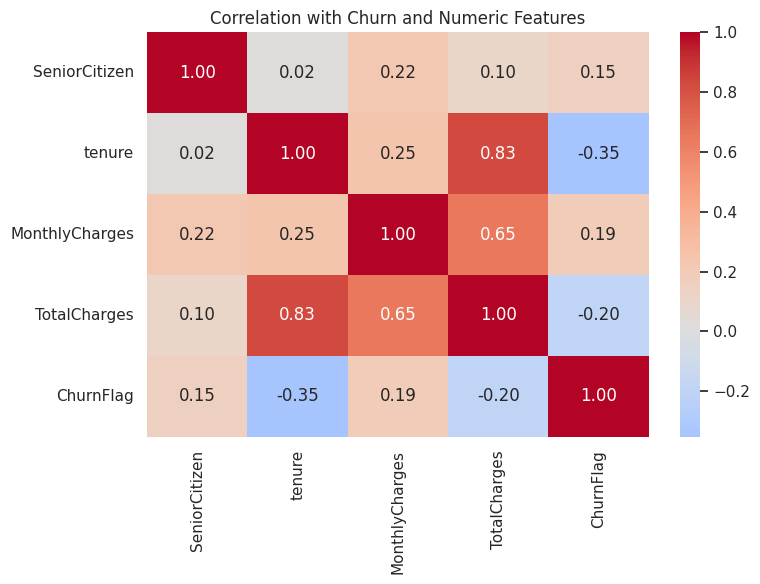

In [16]:
numeric_for_corr = data[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "ChurnFlag"]]
corr = numeric_for_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation with Churn and Numeric Features")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "correlation with churn.PNG", dpi=160, bbox_inches="tight")
plt.show()

## 6. SQL Analysis

In [17]:
conn = sqlite3.connect(":memory:")
sql_data = data.drop(columns=["ChurnFlag"]).copy()
sql_data.to_sql("telco_customer_churn", conn, index=False, if_exists="replace")

query = '''
SELECT Contract,
       COUNT(*) AS customers,
       SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned,
       ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM telco_customer_churn
GROUP BY Contract
ORDER BY churn_rate_pct DESC;
'''
display(pd.read_sql_query(query, conn))

,Contract,customers,churned,churn_rate_pct
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


### Revenue at Risk

In [18]:
query = '''
SELECT ROUND(SUM(MonthlyCharges), 2) AS monthly_revenue_at_risk
FROM telco_customer_churn
WHERE Churn = 'Yes';
'''
display(pd.read_sql_query(query, conn))

,monthly_revenue_at_risk
0,139130.85


### High-Risk Segment

In [19]:
query = '''
SELECT Contract, PaymentMethod, InternetService,
       COUNT(*) AS customers,
       ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM telco_customer_churn
GROUP BY Contract, PaymentMethod, InternetService
HAVING COUNT(*) >= 50
ORDER BY churn_rate_pct DESC
LIMIT 10;
'''
display(pd.read_sql_query(query, conn))

,Contract,PaymentMethod,InternetService,customers,churn_rate_pct
0,Month-to-month,Electronic check,Fiber optic,1307,60.37
1,Month-to-month,Mailed check,Fiber optic,201,50.75
2,Month-to-month,Bank transfer (automatic),Fiber optic,327,45.57
3,Month-to-month,Credit card (automatic),Fiber optic,293,41.64
4,Month-to-month,Electronic check,DSL,474,40.51
5,Month-to-month,Mailed check,DSL,367,30.79
6,Month-to-month,Credit card (automatic),DSL,185,27.03
7,One year,Electronic check,Fiber optic,196,26.02
8,Month-to-month,Mailed check,No,325,20.62
9,Month-to-month,Bank transfer (automatic),No,65,20.00


## 7. Machine Learning Model Evaluations and Predictions

### Preparing Features

For modelling, `customerID` is removed. Numerical features are imputed and standardized, while categorical features are imputed and one-hot encoded inside a preprocessing pipeline. This avoids data leakage and keeps the same preprocessing logic for training and testing data.

In [20]:
X = data.drop(columns=["Churn", "ChurnFlag", "customerID"])
y = data["ChurnFlag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

dense_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Training rows: 4930
Testing rows: 2113
Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Baseline Classification Algorithms

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1500, class_weight="balanced", random_state=42),
    "SVM (Linear)": SVC(kernel="linear", probability=True, random_state=42, class_weight="balanced"),
    "Kernel SVM": SVC(kernel="rbf", probability=True, random_state=42, class_weight="balanced"),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=15),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1, class_weight="balanced"),
    "Adaboost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boost": GradientBoostingClassifier(random_state=42)
}

pipelines = {}
for name, model in models.items():
    prep = dense_preprocessor if name == "Naive Bayes" else preprocessor
    pipelines[name] = Pipeline([
        ("preprocessor", prep),
        ("model", model)
    ])

# Soft voting combines three complementary models.
pipelines["Voting Classifier"] = VotingClassifier(
    estimators=[
        ("lr", clone(pipelines["Logistic Regression"])),
        ("rf", clone(pipelines["Random Forest"])),
        ("gb", clone(pipelines["Gradient Boost"]))
    ],
    voting="soft"
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rows = []
fitted_models = {}
predictions = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    cv_scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
        n_jobs=-1
    )

    fitted_models[name] = pipe
    predictions[name] = pred

    rows.append({
        "Model": name,
        "CV Accuracy": cv_scores["test_accuracy"].mean(),
        "CV Precision": cv_scores["test_precision"].mean(),
        "CV Recall": cv_scores["test_recall"].mean(),
        "CV F1": cv_scores["test_f1"].mean(),
        "CV ROC-AUC": cv_scores["test_roc_auc"].mean(),
        "Test Accuracy": accuracy_score(y_test, pred),
        "Test Precision": precision_score(y_test, pred, zero_division=0),
        "Test Recall": recall_score(y_test, pred, zero_division=0),
        "Test F1": f1_score(y_test, pred, zero_division=0),
        "Test ROC-AUC": roc_auc_score(y_test, prob)
    })

results = pd.DataFrame(rows).sort_values("CV ROC-AUC", ascending=False).reset_index(drop=True)
display(results.round(4))
results.to_csv(OUTPUT_PATH / "model_results.csv", index=False)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Adaboost,0.8041,0.6595,0.5436,0.5948,0.8466,0.7956,0.6411,0.5223,0.5756,0.8427
1,Voting Classifier,0.7986,0.6187,0.6269,0.6225,0.8464,0.7941,0.6109,0.6185,0.6147,0.8416
2,Gradient Boost,0.8034,0.6643,0.5237,0.5853,0.8441,0.7965,0.6541,0.4955,0.5639,0.8402
3,Logistic Regression,0.7473,0.5155,0.8089,0.6294,0.8432,0.7435,0.5109,0.7968,0.6226,0.8444
4,Random Forest,0.7959,0.6557,0.4855,0.5577,0.8283,0.7790,0.6068,0.4759,0.5335,0.8147
5,Kernel SVM,0.7438,0.5117,0.7844,0.6191,0.8281,0.7444,0.5122,0.7843,0.6197,0.8209
6,Naive Bayes,0.6951,0.4596,0.8463,0.5956,0.8213,0.6914,0.4560,0.8396,0.5910,0.8074
7,K-Nearest Neighbours,0.7834,0.5969,0.5657,0.5807,0.8205,0.7738,0.5748,0.5686,0.5717,0.8195
8,SVM (Linear),0.7049,0.4686,0.8372,0.6009,0.8168,0.6910,0.4546,0.8217,0.5854,0.8179
9,Decision Tree,0.7162,0.4784,0.7569,0.5860,0.8051,0.7416,0.5090,0.7576,0.6089,0.8177


### Accuracy Score Comparison

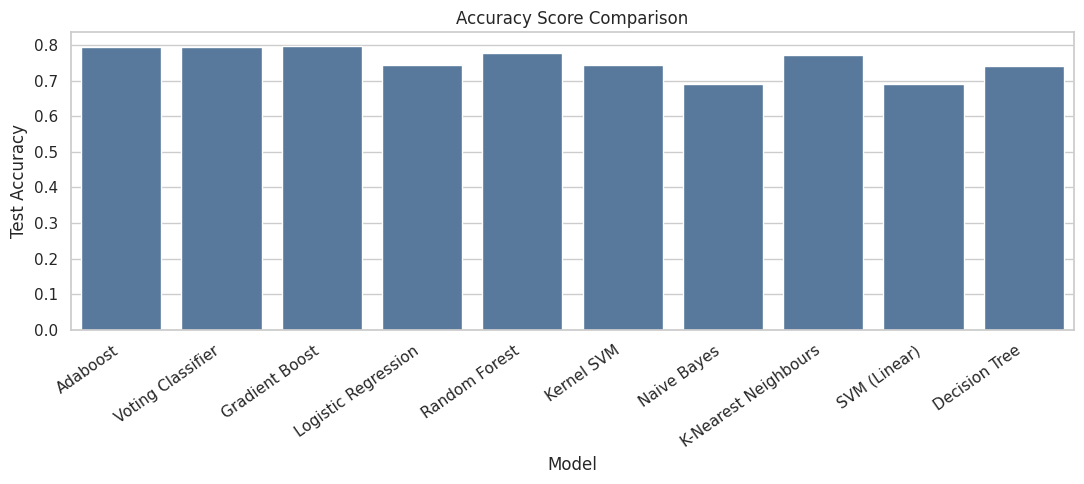

In [22]:
plt.figure(figsize=(11, 5))
sns.barplot(data=results, x="Model", y="Test Accuracy", color=sns.color_palette()[0])
plt.title("Accuracy Score Comparison")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "Accuracy score comparison.PNG", dpi=160, bbox_inches="tight")
plt.show()

### ROC-AUC Comparison

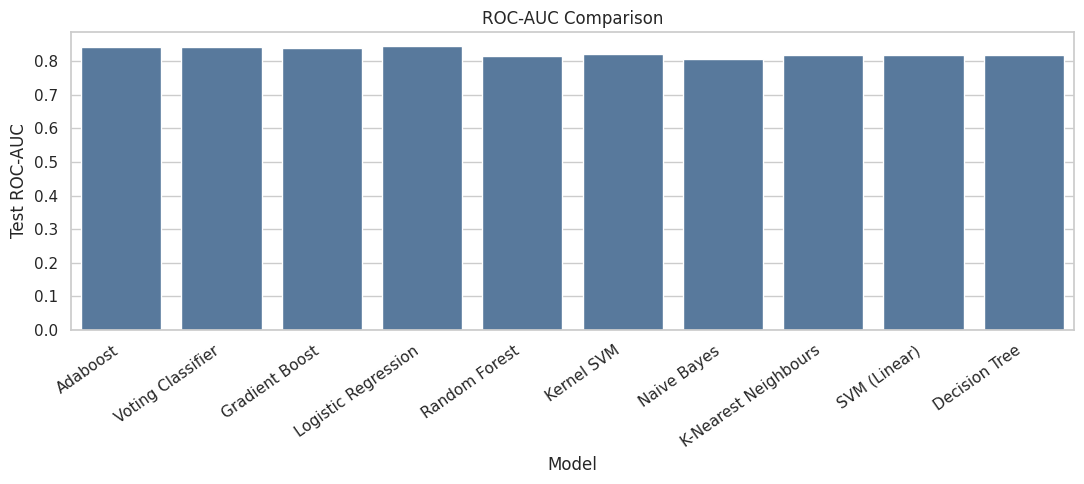

In [23]:
plt.figure(figsize=(11, 5))
sns.barplot(data=results, x="Model", y="Test ROC-AUC", color=sns.color_palette()[0])
plt.title("ROC-AUC Comparison")
plt.ylabel("Test ROC-AUC")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "ROC AUC comparison.PNG", dpi=160, bbox_inches="tight")
plt.show()

### Confusion Matrices

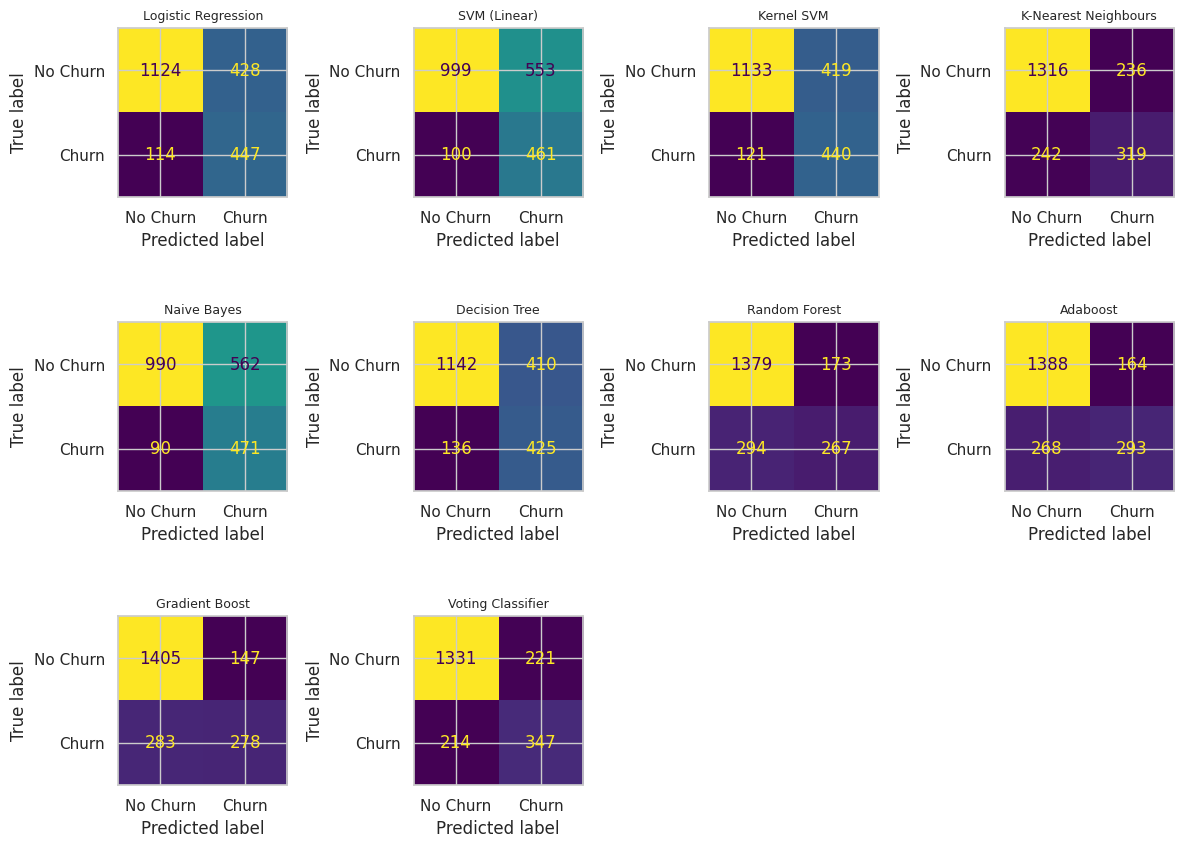

In [24]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(
        ax=ax, colorbar=False
    )
    ax.set_title(name, fontsize=9)

for ax in axes[len(predictions):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "confusion_matrix_models.PNG", dpi=160, bbox_inches="tight")
plt.show()

## 10. Feature Importance

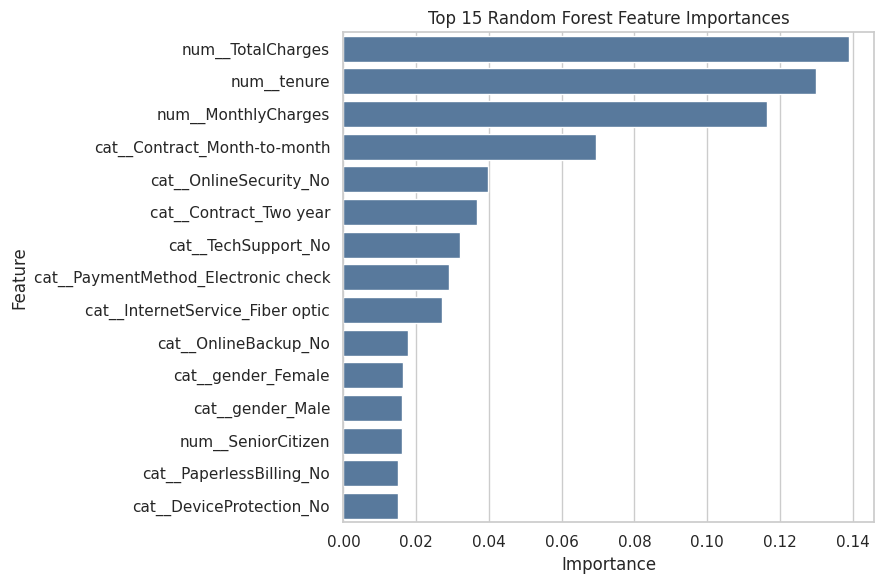

,importance
num__TotalCharges,0.138882
num__tenure,0.129800
num__MonthlyCharges,0.116290
cat__Contract_Month-to-month,0.069503
cat__OnlineSecurity_No,0.039758
cat__Contract_Two year,0.036815
cat__TechSupport_No,0.031982
cat__PaymentMethod_Electronic check,0.029061
cat__InternetService_Fiber optic,0.026992
cat__OnlineBackup_No,0.017749


In [25]:
rf_pipe = fitted_models["Random Forest"]
rf_model = rf_pipe.named_steps["model"]
rf_prep = rf_pipe.named_steps["preprocessor"]

feature_names = rf_prep.get_feature_names_out()
importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=importance.values, y=importance.index, color=sns.color_palette()[0])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "feature importance.PNG", dpi=160, bbox_inches="tight")
plt.show()

display(importance.to_frame("importance"))

## 11. Final Model

In [26]:
best_model_name = results.iloc[0]["Model"]
print("Best model by cross-validated ROC-AUC:", best_model_name)
display(results.head(3).round(4))

final_pred = predictions[best_model_name]
final_prob = fitted_models[best_model_name].predict_proba(X_test)[:, 1]
final_cm = confusion_matrix(y_test, final_pred)

print("Final model metrics")
print("Accuracy :", round(accuracy_score(y_test, final_pred), 4))
print("Precision:", round(precision_score(y_test, final_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, final_pred, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, final_pred, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, final_prob), 4))

Best model by cross-validated ROC-AUC: Adaboost


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Adaboost,0.8041,0.6595,0.5436,0.5948,0.8466,0.7956,0.6411,0.5223,0.5756,0.8427
1,Voting Classifier,0.7986,0.6187,0.6269,0.6225,0.8464,0.7941,0.6109,0.6185,0.6147,0.8416
2,Gradient Boost,0.8034,0.6643,0.5237,0.5853,0.8441,0.7965,0.6541,0.4955,0.5639,0.8402


Final model metrics
Accuracy : 0.7956
Precision: 0.6411
Recall   : 0.5223
F1 Score : 0.5756
ROC-AUC  : 0.8427


## 12. Business Recommendations

- Focus retention activity on **month-to-month customers**, especially early in their customer lifecycle.
- Review the customer experience and pricing of the **fiber optic** segment.
- Investigate why **electronic check** customers have substantially higher churn.
- Use churn probabilities to prioritize customers with both **high charges and high predicted risk**.
- Encourage suitable customers to move from month-to-month plans to longer contracts.
- Treat model output as a prioritization tool rather than proof that a specific service causes churn.

## 13. Limitations and Future Improvements

- This dataset represents one telecom customer population and may not generalize to every provider.
- Associations found during EDA do not prove causation.
- Future work could include hyperparameter tuning, threshold optimization, customer lifetime value, explainable AI and a deployment/API layer.


In [27]:
conn.close()
print("Analysis completed successfully.")

Analysis completed successfully.
